# **Model 1 Parameters:**
## **Inputs:** SMILES strings of chemical structures
## **Outputs:** Predicted pDC50 values against ZBTB11 and IKZF1
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning
### Manual splitting of data based on chemical scaffolds
* Train: ALV-alkyl linkers and MR2-urea and MR2-ureaAlkyl
* Validation: ALV-piperidine/pyrrolidine/triazole linkers and MR2-amides
* Test: Everything else

**Package installs and file loading**

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model1"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model1


In [ ]:
!pip install optuna lightning chemprop

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 37.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import optuna
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lightning import pytorch as pl
from chemprop import data, models, nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [ ]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Model Training and Evaluation Pipeline**

Step 1: Loading data and building PyTorch DataLoaders (4 Tasks)...


[I 2026-03-03 10:49:16,823] A new study created in memory with name: no-name-c3c72d5d-076f-48ec-afb9-8d425b8c6bdc
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Step 2: Running Optuna to find the best model architecture...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loading `train_dataloader` to estimate number of stepping batches.
INFO:lightning.pytorch.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  815 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  723 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Step 4: Predicting on the Test Set and calculating Efficiency Scores...



--- Top Predicted Selective Compounds (Efficiency-based) ---
                                              SMILES  ZBTB11_Efficiency  \
0  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...           1.040611   
8  COC1=CC=C(C2(CCC2)NS(NC3=CC(C4)=C(C=C3)C(N4C(C...           2.105954   
6  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)CNCC4=CC=CC=C4...           1.835739   
7  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)CNCC4=CC=C(OC)...           1.616117   
3  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...           1.541671   

   IKZF1_Efficiency  Selectivity_Score  
0          1.968078          -0.927467  
8          3.273275          -1.167321  
6          3.211749          -1.376011  
7          3.053675          -1.437558  
3          3.121731          -1.580060  

Step 5: Evaluating model performance metrics...

--- Regression Evaluation Metrics ---
    Endpoint  N_Valid_Points   RMSE    MAE     R²  Pearson_r
ZBTB11_pDC50               8  1.000  0.791 -0.034      0.252
 ZBTB11_Dmax              11 21

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


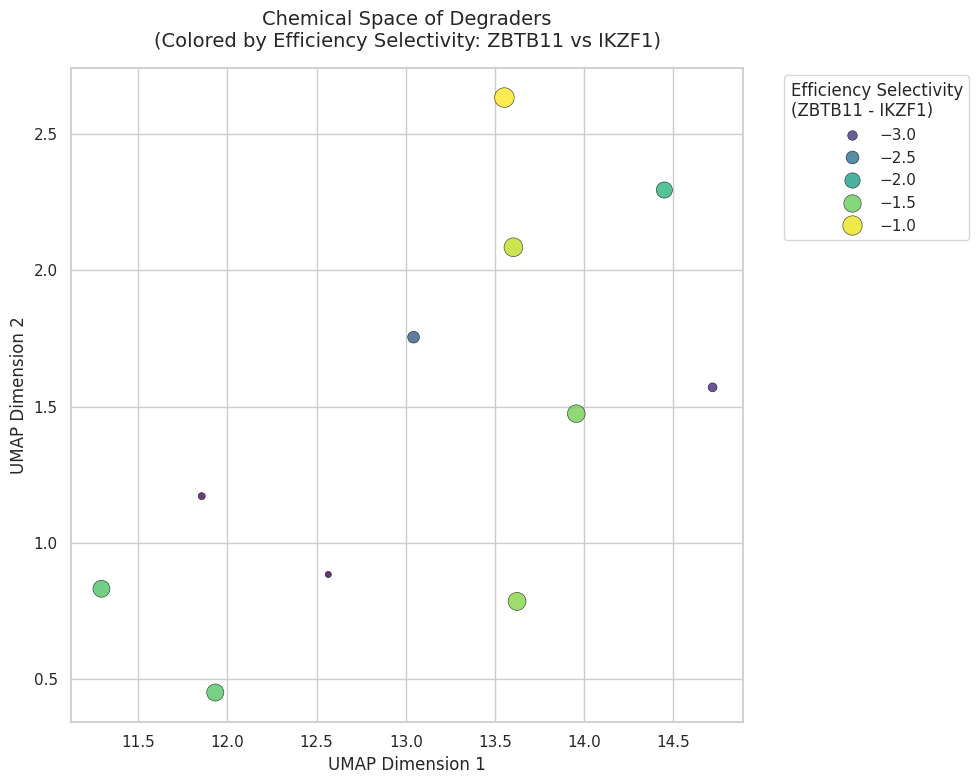

Saved chemical space plot to 'efficiency_selectivity_umap.png'. Workflow complete!


In [ ]:
# ===================================================================
# STEP 1: LOAD DATA WITH 4 TARGETS & HANDLE NaNs
# ===================================================================
print("Step 1: Loading data and building PyTorch DataLoaders (4 Tasks)...")

df = pd.read_csv("zbtb11_mgd_input.csv")

train_df = df[df['Dataset'] == 'Train']
val_df = df[df['Dataset'] == 'Val']
test_df = df[df['Dataset'] == 'Test']

def create_datapoints(dataframe):
    smiles = dataframe['SMILES'].tolist()
    targets = dataframe[[
        'ZBTB11_pDC50', 'ZBTB11_Dmax',
        'IKZF1_pDC50', 'IKZF1_Dmax'
    ]].values.tolist()

    return [data.MoleculeDatapoint.from_smi(smi, y) for smi, y in zip(smiles, targets)]

train_dset = data.MoleculeDataset(create_datapoints(train_df))
val_dset = data.MoleculeDataset(create_datapoints(val_df))
test_dset = data.MoleculeDataset(create_datapoints(test_df))

output_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)
output_transform = nn.transforms.UnscaleTransform.from_standard_scaler(output_scaler)

train_loader = data.build_dataloader(train_dset, shuffle=True)
val_loader = data.build_dataloader(val_dset, shuffle=False)
test_loader = data.build_dataloader(test_dset, shuffle=False)


# ===================================================================
# STEP 2: HYPERPARAMETER TUNING WITH OPTUNA
# ===================================================================
print("\nStep 2: Running Optuna to find the best model architecture...")

def objective(trial):
    depth = trial.suggest_int("depth", 2, 6)
    d_h = trial.suggest_int("d_h", 300, 1200, step=100)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    n_layers = trial.suggest_int("n_layers", 1, 3)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    ffn = nn.RegressionFFN(
        n_tasks=4,
        input_dim=mp.output_dim,
        hidden_dim=d_h,
        n_layers=n_layers,
        dropout=dropout,
        output_transform=output_transform
    )
    chemprop_model = models.MPNN(mp, agg, ffn)

    trainer = pl.Trainer(
        accelerator="gpu",
        max_epochs=50,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False
    )
    trainer.fit(chemprop_model, train_loader, val_loader)

    return trainer.callback_metrics["val_loss"].item()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# ===================================================================
# STEP 3: TRAIN THE FINAL OPTIMIZED MODEL
# ===================================================================
print("\nStep 3: Training the final model with optimized parameters...")

best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_ffn = nn.RegressionFFN(
    n_tasks=4,
    input_dim=final_mp.output_dim,
    hidden_dim=best["d_h"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    output_transform=output_transform
)
final_model = models.MPNN(final_mp, final_agg, final_ffn)

final_trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=50,
    enable_progress_bar=True,
    enable_checkpointing=True
)
final_trainer.fit(final_model, train_loader, val_loader)


# ===================================================================
# STEP 4: PREDICT & CALCULATE DEGRADATION EFFICIENCY SCORE
# ===================================================================
print("\nStep 4: Predicting on the Test Set and calculating Efficiency Scores...")

preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_results_df = pd.DataFrame(
    preds_tensor.numpy(),
    columns=[
        'Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax',
        'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax'
    ]
)
test_results_df.insert(0, 'SMILES', test_df['SMILES'].tolist())

# Calculate Degradation Efficiency (Potency x Efficacy Multiplier)
test_results_df['ZBTB11_Efficiency'] = test_results_df['Pred_ZBTB11_pDC50'] * (test_results_df['Pred_ZBTB11_Dmax'] / 100)
test_results_df['IKZF1_Efficiency'] = test_results_df['Pred_IKZF1_pDC50'] * (test_results_df['Pred_IKZF1_Dmax'] / 100)

# Final Selectivity Score based on the new Efficiency metrics
test_results_df['Selectivity_Score'] = test_results_df['ZBTB11_Efficiency'] - test_results_df['IKZF1_Efficiency']

test_results_df = test_results_df.sort_values(by='Selectivity_Score', ascending=False)
print("\n--- Top Predicted Selective Compounds (Efficiency-based) ---")
print(test_results_df[['SMILES', 'ZBTB11_Efficiency', 'IKZF1_Efficiency', 'Selectivity_Score']].head())

test_results_df.to_csv("zbtb11_mgd_output.csv", index=False)


# ===================================================================
# STEP 5: EVALUATE REGRESSION METRICS
# ===================================================================
print("\nStep 5: Evaluating model performance metrics...")

true_cols = ['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']
pred_cols = ['Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax', 'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax']

evaluation_results = []

for true_col, pred_col in zip(true_cols, pred_cols):

    y_true = test_df[true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_model_metrics.csv", index=False)
print("\n--- Regression Evaluation Metrics ---")
print(metrics_df.to_string(index=False))


# ===================================================================
# STEP 6: EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
# ===================================================================
print("\nStep 6: Extracting learned 3D fingerprints from the Chemprop model...")

final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        molecule_embeddings = final_model.fingerprint(batch.bmg, batch.V_d, batch.X_d)
        learned_fingerprints.append(molecule_embeddings.numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# ===================================================================
# STEP 7: UMAP DIMENSIONALITY REDUCTION & PLOTTING
# ===================================================================
print("\nStep 7: Reducing dimensions with UMAP and plotting...")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=test_results_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Selectivity_Score',
    palette='viridis',
    size='Selectivity_Score',
    sizes=(20, 200),
    alpha=0.8,
    edgecolor="black"
)

plt.title("Chemical Space of Degraders\n(Colored by Efficiency Selectivity: ZBTB11 vs IKZF1)", fontsize=14, pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Efficiency Selectivity\n(ZBTB11 - IKZF1)")
plt.tight_layout()

plt.savefig("efficiency_selectivity_umap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved chemical space plot to 'efficiency_selectivity_umap.png'. Workflow complete!")